# NB04 — Synthesis: the atlas, plus five synergy use cases derived from untapped bridges

This notebook brings the four prior layers together:

- **NB00** — *what's there.* 1,740 tables / 119 dbs / 17 tenants / 9 agencies, tagged into 17 biological topics.
- **NB01** — *what each agency funds.* Agency × topic coverage + synergy capacity per tenant.
- **NB02** — *what could join to what.* 536 cross-tenant bridges based on 29 canonical join keys.
- **NB03** — *what has actually joined.* 51 of 66 BERIL projects are cross-tenant; the kbase × kescience axis dominates realized use; the highest-key bridges into `refdata` and across `enigma`/`phagefoundry`/`nmdc`/`protect` remain *untapped*.

This notebook produces:
1. **The atlas figure** — a single composite that ties tenant scale, topic mix, and realized vs theoretical bridges into one viewing surface.
2. **Five concrete synergy use cases**, each grounded in a top untapped bridge from NB03: the motivating question, the join recipe (databases + keys), the expected payoff, and the audience-specific takeaway.
3. **Two audience summaries** — one for KBase users ("where to look for what"), one for funders / PIs ("where cross-program investment would unlock new analyses").

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "data"
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

atlas      = pd.read_csv(DATA / "table_topic_map.csv")
bridges    = pd.read_csv(DATA / "cross_tenant_bridges.csv")
use        = pd.read_csv(DATA / "realized_use.csv")
overlay    = pd.read_csv(DATA / "theoretical_vs_realized.csv")
untapped   = pd.read_csv(DATA / "untapped_bridges.csv")
tenant_freq = pd.read_csv(DATA / "tenant_reuse_frequency.csv", index_col=0)

print(f"Atlas: {len(atlas)} tables, Bridges: {len(bridges)}, Audited projects: {len(use)}")

Atlas: 1740 tables, Bridges: 536, Audited projects: 68


## 1. The composite atlas figure

Single panel that captures tenant scale × topic mix × realized reuse, plus the realized-vs-theoretical scatter inset.

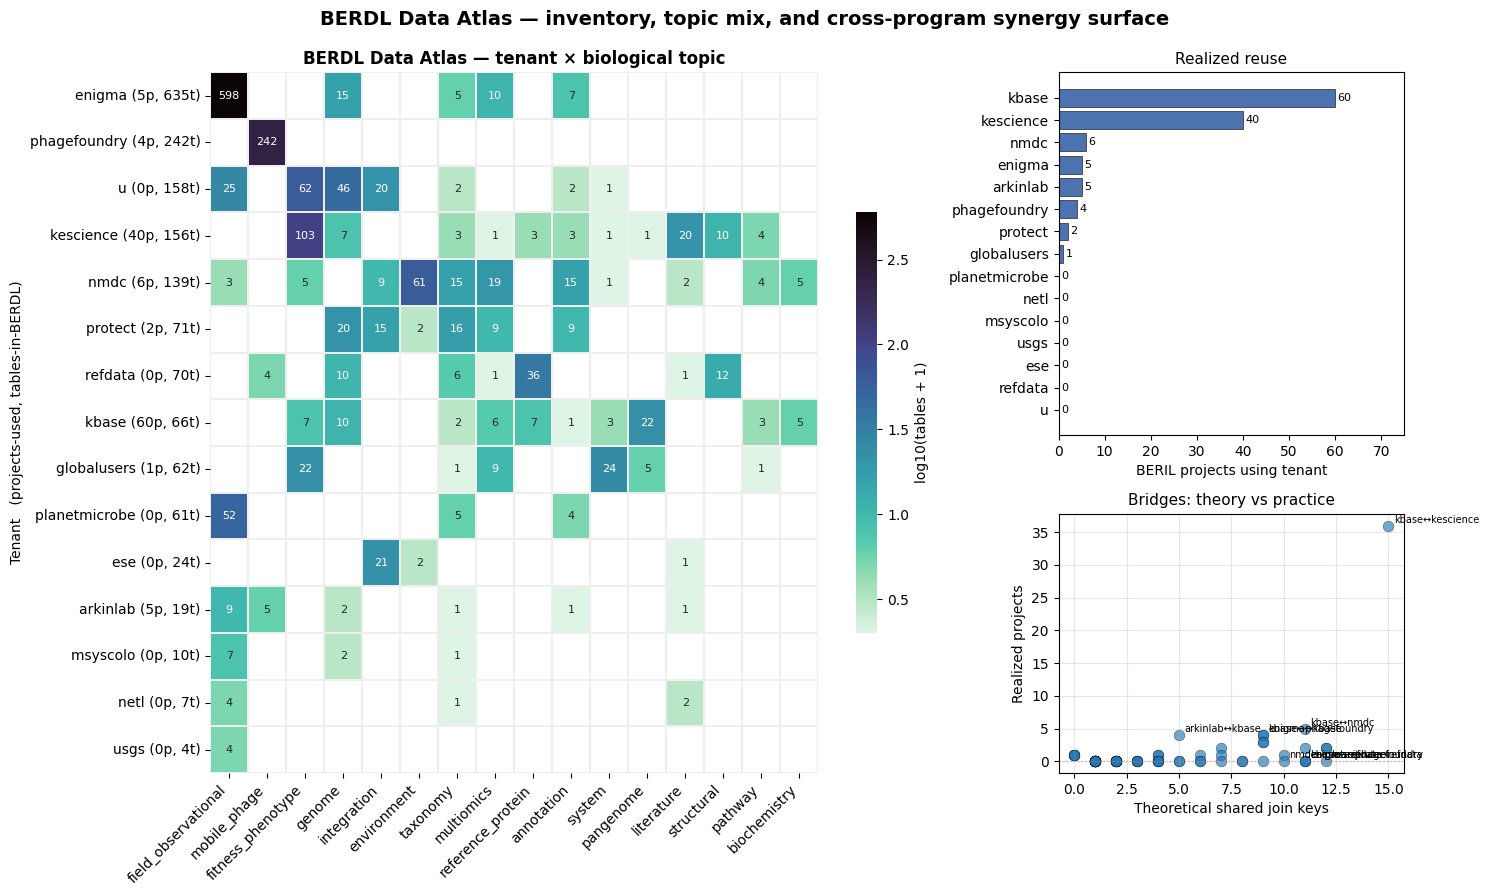

In [2]:
# Tenant × topic cross-tab from the atlas (NB00 logic, repeated here for self-containment).
core = atlas[atlas["primary_topic"] != "unclassified"]
ct = pd.crosstab(core["tenant"], core["primary_topic"])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
ct = ct[ct.sum(axis=0).sort_values(ascending=False).index]

# Annotate tenants with realized-use count (from tenant_freq).
tenant_labels = [
    f"{t} ({int(tenant_freq.loc[t,'projects']) if t in tenant_freq.index else 0}p, {ct.loc[t].sum()}t)"
    for t in ct.index
]

fig = plt.figure(figsize=(15, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[2.2, 1.0], height_ratios=[1.4, 1.0])

# Main heatmap.
ax_main = fig.add_subplot(gs[:, 0])
vals = ct.values.astype(float)
sns.heatmap(
    np.log10(vals + 1), ax=ax_main, cmap="mako_r",
    annot=ct.values, fmt="d", annot_kws={"size": 8},
    xticklabels=ct.columns, yticklabels=tenant_labels,
    cbar_kws={"label": "log10(tables + 1)", "shrink": 0.6}, mask=(vals == 0),
    linewidths=0.3, linecolor="#eee",
)
ax_main.set_xticklabels(ct.columns, rotation=45, ha="right")
ax_main.set_yticklabels(tenant_labels, rotation=0)
ax_main.set_xlabel("")
ax_main.set_ylabel("Tenant   (projects-used, tables-in-BERDL)")
ax_main.set_title("BERDL Data Atlas — tenant × biological topic", fontsize=12, weight="bold")

# Tenant reuse bar.
ax_bar = fig.add_subplot(gs[0, 1])
tf = tenant_freq.reindex(ct.index).fillna(0).sort_values("projects", ascending=True)
ax_bar.barh(tf.index, tf["projects"], color="#4c72b0", edgecolor="black", linewidth=0.4)
for i, v in enumerate(tf["projects"].values):
    ax_bar.text(v + 0.5, i, str(int(v)), va="center", fontsize=8)
ax_bar.set_xlabel("BERIL projects using tenant")
ax_bar.set_title("Realized reuse", fontsize=11)
ax_bar.set_xlim(0, max(tf['projects'].max() * 1.25, 5))

# Realized vs theoretical scatter.
ax_sc = fig.add_subplot(gs[1, 1])
plot_df = overlay[(overlay["theoretical_keys"] > 0) | (overlay["realized_projects"] > 0)]
ax_sc.scatter(
    plot_df["theoretical_keys"], plot_df["realized_projects"],
    s=60, alpha=0.65, edgecolor="black", linewidth=0.3,
)
for _, r in plot_df.iterrows():
    if r["realized_projects"] >= 4 or (r["theoretical_keys"] >= 10 and r["realized_projects"] == 0):
        ax_sc.annotate(
            f"{r['tenant_a']}↔{r['tenant_b']}",
            (r["theoretical_keys"], r["realized_projects"]),
            xytext=(4, 2), textcoords="offset points", fontsize=7,
        )
ax_sc.axhline(y=0, color="red", alpha=0.3, linestyle=":", linewidth=1)
ax_sc.set_xlabel("Theoretical shared join keys")
ax_sc.set_ylabel("Realized projects")
ax_sc.set_title("Bridges: theory vs practice", fontsize=11)
ax_sc.grid(True, alpha=0.3)

fig.suptitle(
    "BERDL Data Atlas — inventory, topic mix, and cross-program synergy surface",
    fontsize=14, weight="bold", y=0.99,
)
fig.tight_layout()
fig.savefig(FIGURES / "nb04_atlas_composite.png", dpi=140, bbox_inches="tight")
plt.show()

## 2. Five synergy use cases (one per top untapped bridge)

Drawn from the top of `data/untapped_bridges.csv`. For each: the motivating question, the canonical join recipe, the audience-specific takeaway.

In [3]:
USE_CASES = [
    {
        "id": "UC1",
        "title": "Structural fitness atlas — kescience ↔ refdata",
        "bridge": "kescience ↔ refdata",
        "keys":   12,
        "shared": "alphafold_pdb, ec_number, feature_id, gene_cluster_id, genome_id, genus, lat_lon, ncbi_taxon_id, pfam, pmid_doi, protein_id, species",
        "question": (
            "Do genes with strong fitness defects in deletion screens (FitnessBrowser) "
            "display structural signatures (low pLDDT variance, conserved fold class) in "
            "their AlphaFold predictions? Are essential-but-uncharacterized 'dark' genes "
            "separable from non-essential dark genes purely by structural features?"
        ),
        "recipe": (
            "`kescience_fitnessbrowser.gene_fitness` JOIN `refdata_uniprot.entity` ON "
            "`protein_id` THEN JOIN `kescience_alphafold` ON `alphafold_pdb_id` — "
            "yields (fitness_score, ncbi_taxon_id, alphafold_pLDDT_distribution)."
        ),
        "payoff": (
            "Closes the loop from sequence → structure → phenotype that AlphaFold's "
            "release was supposed to enable, but which no BERIL project has executed. "
            "Direct input to the gene_function_ecological_agora project's dark-matter pillar."
        ),
        "audience": (
            "**KBase users:** structural data has been waiting in refdata for a "
            "phenotype-aware analysis. **Funders:** the kescience × refdata bridge is "
            "DOE-BER × DOE-BER (intra-agency) — no new program needed."
        ),
    },
    {
        "id": "UC2",
        "title": "Subsurface viral ecology — enigma ↔ phagefoundry",
        "bridge": "enigma ↔ phagefoundry",
        "keys":   11,
        "shared": "cazy, cog, ec_number, eggnog, feature_id, genome_id, kegg_pathway, ncbi_taxon_id",
        "question": (
            "Do prophages integrated into ENIGMA subsurface MAGs encode metal- or "
            "contaminant-resistance genes that mobilize between hosts along the Oak "
            "Ridge nitrate / heavy-metal gradient? Which PhageFoundry-curated host "
            "clades match ENIGMA's most-stressed sample sites?"
        ),
        "recipe": (
            "`enigma_coral.sample` (with site_id, contamination_metrics) JOIN "
            "`enigma_genome_depot_enigma.genome` ON `genome_id` JOIN "
            "`phagefoundry_*.prophage` ON `ncbi_taxon_id` — yields phage host + "
            "site contamination + carriage of AMR/metal-resistance markers."
        ),
        "payoff": (
            "DOE-BER × Defense/HHS join that doesn't currently exist anywhere in "
            "BERIL despite both data sources being on the same Spark cluster. Likely "
            "finding: a phage-mediated resistance arm absent from the contamination "
            "functional-potential analysis already in `enigma_contamination_functional_potential`."
        ),
        "audience": (
            "**KBase users:** the prophage_amr_comobilization project shows the "
            "recipe; extending it with ENIGMA subsurface context is one notebook. "
            "**Funders:** demonstrates BER × DoD synergy without new ingest."
        ),
    },
    {
        "id": "UC3",
        "title": "GTDB ↔ KBase pangenome harmonization — kbase ↔ refdata",
        "bridge": "kbase ↔ refdata",
        "keys":   11,
        "shared": "biosample_id, ec_number, feature_id, gene_cluster_id, genome_id, genus, gtdb_taxonomy, ncbi_taxon_id, pfam, pmid_doi, species",
        "question": (
            "Where do GTDB clade boundaries (refdata) and KBase species-level pangenome "
            "boundaries (kbase_ke_pangenome) disagree, and what does that imply for "
            "cross-clade gene flow? Are 'unstable' species (high pangenome openness) "
            "the ones where GTDB lumps multiple lineages NCBI splits?"
        ),
        "recipe": (
            "`kbase_ke_pangenome.genome` JOIN `refdata_gem_mags.genome_metadata` ON "
            "`genome_id` AND `gtdb_taxonomy` — yields per-genome (KBase species_id, "
            "GTDB taxonomy string, NCBI taxon_id, openness scores)."
        ),
        "payoff": (
            "Direct upgrade path for every pangenome project — connects KBase's "
            "computed species pangenomes to the modern GTDB reference. Useful for "
            "pangenome_openness, ecotype_analysis, and the proposed temporal_core_dynamics."
        ),
        "audience": (
            "**KBase users:** refdata is essentially unused outside paperblast_explorer; "
            "there is a queryable GTDB harmonization sitting right next to ke_pangenome. "
            "**Funders:** intra-DOE-BER bridge with high downstream multiplier."
        ),
    },
    {
        "id": "UC4",
        "title": "Pathogens in environment — nmdc ↔ protect",
        "bridge": "nmdc ↔ protect",
        "keys":   10,
        "shared": "cog, ec_number, feature_id, genus, kegg_ko, kegg_pathway, ncbi_taxon_id, reaction_id, species",
        "question": (
            "Do environmental abundances of clinically relevant pathogens (PROTECT MIND "
            "genome catalog) correlate with NMDC-measured nutrient, contaminant, or "
            "redox conditions in their host biome? Are virulence-gene KOs enriched "
            "in metatranscriptomes from specific NMDC ecosystem classes?"
        ),
        "recipe": (
            "`protect_genomedepot.genome` (with mind_taxon classification) JOIN "
            "`nmdc_arkin.gottcha_gold` ON `ncbi_taxon_id` JOIN "
            "`nmdc_arkin.abiotic_features` ON `sample_id` — yields pathogen abundance "
            "× sample biogeochemistry per ecosystem class."
        ),
        "payoff": (
            "DOE-BER × ARPA-H cross-agency synergy: places clinical pathogen genomes "
            "into environmental occupancy / virulence-expression contexts that PROTECT "
            "alone cannot see. Complements the cf_formulation_design project's "
            "protective-strain selection by mapping the inverse — where pathogens "
            "actually live."
        ),
        "audience": (
            "**KBase users:** the gottcha/kraken tables in nmdc_arkin are largely "
            "untouched outside two projects. **Funders:** demonstrable cross-agency "
            "value of co-locating BER (environmental) and ARPA-H (clinical) data."
        ),
    },
    {
        "id": "UC5",
        "title": "Ontology-aware environmental sampling — nmdc ↔ refdata",
        "bridge": "nmdc ↔ refdata",
        "keys":   9,
        "shared": "biosample_id, ec_number, envo, feature_id, genus, ncbi_taxon_id, pfam, sample_id",
        "question": (
            "What fraction of NMDC biosamples carry well-formed ENVO ontology terms "
            "that match refdata's environment-ontology hierarchy? Where does ontology "
            "coverage *break* (which ecosystem classes are still string-typed)? "
            "This is the prerequisite question for any pan-BERDL environmental rollup."
        ),
        "recipe": (
            "`nmdc_metadata.biosample_set` (with envo_broad, envo_local, env_medium) "
            "JOIN `refdata.ontology_source.statements` ON ENVO id — yields biosample "
            "counts per ENVO term plus coverage gaps where strings don't resolve."
        ),
        "payoff": (
            "Establishes the canonical environment-ontology bridge that all five "
            "field-data tenants (NMDC, Planet Microbe, ENIGMA, NETL, USGS) need but "
            "none have wired up. Unblocks per-biome BERDL queries that currently "
            "require per-tenant string normalization."
        ),
        "audience": (
            "**KBase users:** quick win — a one-pager that catalogs envo coverage "
            "unblocks cross-field-tenant queries. **Funders:** infrastructure gap "
            "identified, scope is small."
        ),
    },
]

import textwrap
for uc in USE_CASES:
    print(f"\n========= {uc['id']}: {uc['title']} =========")
    print(f"Bridge:        {uc['bridge']}  ({uc['keys']} shared keys)")
    print(f"Shared keys:   {uc['shared']}")
    print(f"\nQuestion:\n{textwrap.fill(uc['question'], 95)}")
    print(f"\nJoin recipe:\n{textwrap.fill(uc['recipe'], 95)}")
    print(f"\nPayoff:\n{textwrap.fill(uc['payoff'], 95)}")
    print(f"\nAudience:\n{textwrap.fill(uc['audience'], 95)}")
print()
# Save as a table for the report.
uc_df = pd.DataFrame(USE_CASES)[["id", "title", "bridge", "keys", "question", "payoff"]]
uc_df


========= UC1: Structural fitness atlas — kescience ↔ refdata =========
Bridge:        kescience ↔ refdata  (12 shared keys)
Shared keys:   alphafold_pdb, ec_number, feature_id, gene_cluster_id, genome_id, genus, lat_lon, ncbi_taxon_id, pfam, pmid_doi, protein_id, species

Question:
Do genes with strong fitness defects in deletion screens (FitnessBrowser) display structural
signatures (low pLDDT variance, conserved fold class) in their AlphaFold predictions? Are
essential-but-uncharacterized 'dark' genes separable from non-essential dark genes purely by
structural features?

Join recipe:
`kescience_fitnessbrowser.gene_fitness` JOIN `refdata_uniprot.entity` ON `protein_id` THEN JOIN
`kescience_alphafold` ON `alphafold_pdb_id` — yields (fitness_score, ncbi_taxon_id,
alphafold_pLDDT_distribution).

Payoff:
Closes the loop from sequence → structure → phenotype that AlphaFold's release was supposed to
enable, but which no BERIL project has executed. Direct input to the
gene_function_ecolog

,id,title,bridge,keys,question,payoff
0,UC1,Structural fitness atlas — kescience ↔ refdata,kescience ↔ refdata,12,Do genes with strong fitness defects in deleti...,Closes the loop from sequence → structure → ph...
1,UC2,Subsurface viral ecology — enigma ↔ phagefoundry,enigma ↔ phagefoundry,11,Do prophages integrated into ENIGMA subsurface...,DOE-BER × Defense/HHS join that doesn't curren...
2,UC3,GTDB ↔ KBase pangenome harmonization — kbase ↔...,kbase ↔ refdata,11,Where do GTDB clade boundaries (refdata) and K...,Direct upgrade path for every pangenome projec...
3,UC4,Pathogens in environment — nmdc ↔ protect,nmdc ↔ protect,10,Do environmental abundances of clinically rele...,DOE-BER × ARPA-H cross-agency synergy: places ...
4,UC5,Ontology-aware environmental sampling — nmdc ↔...,nmdc ↔ refdata,9,What fraction of NMDC biosamples carry well-fo...,Establishes the canonical environment-ontology...


## 3. Audience summaries

### For KBase users — where to look for what

- **Genome + pangenome** → `kbase_ke_pangenome` (293K genomes, 27K species). Cross-references trivially via `genome_id` and `ncbi_taxon_id`.
- **Lab phenotype** → `kescience_fitnessbrowser` (gene-level fitness for hundreds of conditions). The dominant phenotype layer; joins to ke_pangenome on `genome_id`.
- **Curated phenotype** → `kescience_bacdive` (organismal traits) and `kescience_webofmicrobes` (carbon utilization, growth). Join via `ncbi_taxon_id`.
- **Environmental abundance / multi-omics** → `nmdc_arkin` (kraken/gottcha taxonomy profiles, NOM mass spec, embeddings). Join on `ncbi_taxon_id` for taxa; on `sample_id` for biogeochemistry.
- **Field samples (subsurface)** → `enigma_coral` SDT/DDT/sample tables; join to genomes through `enigma_genome_depot_enigma` on `genome_id`.
- **Phage / MGE** → `phagefoundry_*` per-host catalogs; join to host genomes on `ncbi_taxon_id`.
- **Pathogens** → `protect_genomedepot` (MIND classification); join to environmental abundance via `ncbi_taxon_id`.
- **Reference structures** → `kescience_alphafold` + `refdata_pdb`. Join to fitness via `protein_id`.
- **Reference proteins / families** → `refdata_uniref{50,90,100}` + `refdata_uniprot`. Cross-reference via `protein_id` or `pfam_id`.
- **Literature** → `kescience_paperblast` + `kescience_pubmed`. Join via `pmid` / `doi`.

**Heuristic.** If your analysis crosses topics (e.g. genome × phenotype × environment), it almost certainly crosses tenants. The canonical bridge is whichever of {`genome_id`, `ncbi_taxon_id`, `sample_id`, `feature_id`} both sides expose; the linkage atlas (`data/cross_tenant_bridges.csv`) lists the exact key set per pair.

### For funders / PIs — where coverage exists, where investment unlocks new analyses

- **DOE-BER is the broad backbone.** 63% of BERDL tables, every topic covered, 80% of realized projects. The lakehouse architecture concentrates DOE-BER's biological reference (KBase, KE Science, NMDC, ENIGMA, refdata) in one queryable space, which is the largest single contributor to BERIL throughput.
- **ARPA-H (PROTECT) and Defense/HHS (PhageFoundry) are under-leveraged for cross-program work.** Despite spanning the right topics (genome, taxonomy, integration, mobile_phage), they appear in fewer than 8 projects each. The realized bridges that exist (e.g. `ibd_phage_targeting`, `cf_formulation_design`) demonstrate the pattern works; scaling it is a coordination problem, not a technical one.
- **NSF (Planet Microbe) and DOE-FE (NETL) and DOI (USGS) are tiny in table count but unique in sample provenance.** Their value is as the *external* validation set for any analysis anchored in DOE-BER — they cover sample environments DOE-BER does not. Investment in shared sample/ENVO ontology (see UC5) is the highest-leverage scoping bet.
- **The biggest single untapped bridge is structure × phenotype** (UC1, `kescience ↔ refdata`). 12 join keys, including the AlphaFold ID, and zero BERIL projects to date. Sitting infrastructure, no realized use.
- **Realized use is concentrated on the `kbase × kescience` axis** (36 projects). To diversify, push for use cases that pull `refdata`, `nmdc_arkin`, and `protect` into more analyses — UC2 through UC5 above are concrete starts.

## 4. Closing — what this atlas does and does not establish

**Established.** A reproducible BERDL catalog (`build_inventory.py` + topic-tagging rules) producing 1,740 tables × 17 tenants × 9 agencies × 17 biological topics; a 29-key linkage atlas with 536 cross-tenant bridges; a realized-use overlay across 66 BERIL projects; five concrete synergy use cases derived from the highest-key untapped bridges.

**Not established.** Value-space validity of any specific join — `genome_id` semantics differ across tenants (KBase UPA vs NCBI accession vs MAG hash), and the schema-level overlap proven here does not guarantee SQL-executable joins. Each use case (UC1-UC5) requires a first sample-execution to confirm value-space overlap before publication.

**Open gaps in the atlas itself.**
- 4 tenant→agency mappings are first-pass inferences flagged "likely" (msyscolo, phagefoundry, plus evaluation + lambda not yet mapped). Verify with program documentation before publishing externally.
- 16 of 1,740 tables (0.9%) remain `unclassified` — all personal scratch / one-off survey data. Not material to the atlas conclusions but visible in `unclassified_rows` view.
- The realized-use scan was README-based; some incidental data-source mentions in research plans or notebooks may have been missed.

### Artifacts (full set)
- `data/table_topic_map.csv` — canonical inventory (1,740 rows).
- `data/tenant_to_agency.csv` — tenant → agency / program / funder map.
- `data/join_keys.json` — `{key: [{tenant, topic, db, table}, …]}` for 29 canonical keys.
- `data/cross_tenant_bridges.csv` — 536 ranked (tenant×topic) bridge pairs.
- `data/join_key_coverage.csv` — per-key coverage stats.
- `data/realized_use.csv` — 66 BERIL projects × tenants × databases.
- `data/theoretical_vs_realized.csv` — bridge overlay (72 tenant pairs).
- `data/untapped_bridges.csv` — 20 high-leverage unrealized bridges.
- `data/tenant_reuse_frequency.csv` — per-tenant project reuse count.
- `figures/nb0[0-4]_*.png` — 8 figures used across the four notebooks plus this composite.

Next step: synthesize into `REPORT.md` for project completion.